#### Implementation of Neural Network from scratch

![Session2_DL.jpg](attachment:Session2_DL.jpg)

The following code is implementing the neural network for the non-linear xor logic from scratch using the above equations.

In [1]:

import numpy as np
from matplotlib import pyplot as plt

In [2]:
# Defining some sample input x and output y
x=np.array(([0,0],[0,1],[1,0],[1,1]))
y=np.array(([0],[1],[1],[0]))

In [3]:
x_b=np.array(([1,0,0],[1,0,1],[1,1,0],[1,1,1])) # Defining the input with bias 'b'

In [4]:
# define the ANN archi
inp_size=3 # 3 neurons in the input layer including one for bias
hid_size=3 # 3 neurons in the hidden layer
out_size=1 # 1 neuron for output

In [5]:
#Randomly intialize the weight between input and hidden layer for the size of inp_size x hid_size
w1=np.random.randn(inp_size,hid_size)
w1

array([[ 0.55377062, -0.79104898,  0.4005481 ],
       [-1.78586321, -1.58087723,  1.01157547],
       [ 1.02219261, -0.02414615,  1.05392699]])

In [6]:
#Randomly intialize the weight between hidden and output layer for the size of hid_size x out_size
w2=np.random.randn(hid_size,out_size)
w2

array([[ 0.38115615],
       [-0.15609756],
       [ 1.33531625]])

In [7]:
# define a sigmoidal activation function
def sigmoid(z):
    sig=1/(1+np.exp(-z))
    return sig

# define the logic of feed forward path 
def forward(x):
    z1=np.dot(x,w1)
    y1=sigmoid(z1)
    z2=np.dot(y1,w2)
    out=sigmoid(z2)
    return out,y1

# define the operations of backward probagation
def backward(x,y,w1,w2,y1,out):
    out_err=y-out
    out_delta=out_err*(out*(1-out))
    
    y1_err=np.dot(out_delta,w2.T)
    y1_delta=y1_err*(y1*(1-y1))
    
    w2+=np.dot(y1.T,out_delta)  # consider alpha=1  
    w1+=np.dot(x.T,y1_delta)
    
    return w1,w2

# Train the whole network with forward and bacward logic
def train(x,y):
    [out,y1]=forward(x)
    backward(x,y,w1,w2,y1,out)
    return w1,w2,out

# predict the output for given input by applying trained weights
def predict(tes):
    [out,y1]=forward(tes)
    pred=out
    return pred


In [8]:
#Training the model with 1000 iterations
loss=np.zeros([1000,1],dtype=float)
for i in range(1000):
    [w1,w2,out]=train(x_b,y)
    loss[i]=np.mean(np.square(y-out))  
    #print(loss[i])

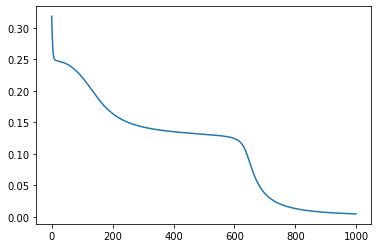

In [9]:
plt.plot(loss)

In [10]:
tes=np.array(([1,0,0],[1,0,1],[1,1,0],[1,1,1]))
pred=predict(tes)
print(pred)

[[0.04950771]
 [0.91771387]
 [0.95542937]
 [0.08659703]]


In [11]:
y

array([[0],
       [1],
       [1],
       [0]])

#At second and third instant the predicted probability is high (above 0.95). The actual output for these instants are 1. The neural network we designed from scratch, predicting the output correctly with respect to this data

In [12]:
w1 # Final updated first stage weights

array([[ 2.53120663,  0.0715815 , -1.73537345],
       [-4.33345598, -4.8122976 ,  3.89109855],
       [ 6.39373416,  1.85614589,  6.25983933]])

In [13]:
w2 # Final updated second stage weights

array([[-7.25104489],
       [ 5.95889761],
       [ 4.50800475]])

In [14]:
from sklearn.linear_model import LogisticRegression
logit=LogisticRegression()
logit.fit(x,y)
ypred=logit.predict(x)
ypred

/home/sagarikaborah/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


array([0, 0, 0, 0])

#We can clearly see that logistic regression (Single neuron) is not predicting the output correctly as the data is non-linear (xor)